In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=6)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [3]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
    #setParametersALN(aln)
                    
def setParametersALN(model):
    model.params.rates_exc_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.rates_inh_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mufe_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.mufi_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.IA_init = np.array( [[0. * 200. * 0.5 ]] )  # pA
    model.params.seem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.seim_init = np.array( [[0. * 0.5 * 0.5 ]] )   
    model.params.seev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.seiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siim_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mue_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))
    model.params.mui_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))

In [4]:
tol = 1e-24

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

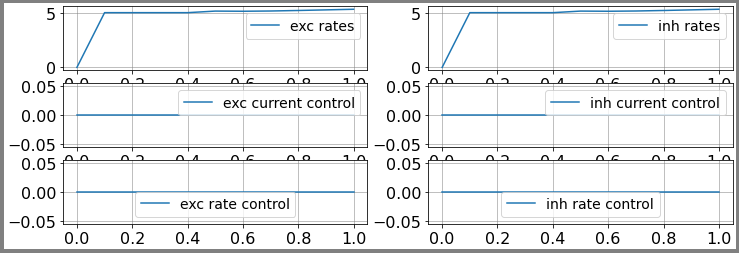

In [5]:
aln = RateModel()

aln.params['duration'] = 1.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.2
aln.params.di = 0.2

aln.params.cee = 1.
aln.params.Jee_max = 1.

aln.params.cie = 1.
aln.params.Jie_max = 1.

aln.params.cei = 1.
aln.params.Jei_max = 1.

aln.params.cii = 1.
aln.params.Jii_max = 1.

aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

setParametersALN(aln)

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

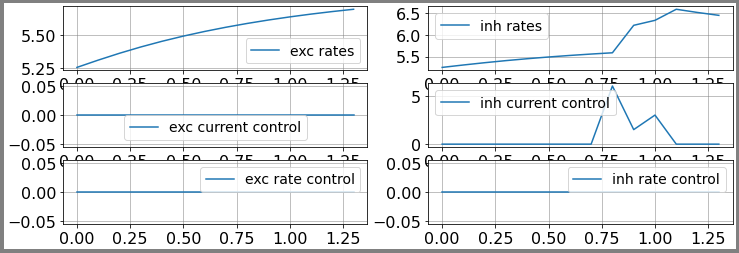

[5.40950777 5.45276396 5.49187137 5.52718585 5.55908435 5.5879078
 6.21395789 6.32750309 6.57978415 6.50658681 6.44112442]


In [31]:
setinitvars(high_state_vars)

dur = 1.
dur_pre = 0.3
dur_post = 0.3

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

aln.params.duration = dur + dur_pre

control_ind1 = [1]
prec_var1 = [1]

if control_ind1[0] == 0 or control_ind1[0] == 1:
    max_cntrl = 15.
    min_cntrl = -15.
else:
    max_cntrl = 0.1
    min_cntrl = 0.

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind1:
    control0[0,j,n_pre + 4] = 0.2 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 5] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 6] = 0.2 * max_cntrl #+ 0.3 * min_cntrl

plotFunc.plot_traces(aln, control0)

aln.params.duration = dur
target1 = aln.getZeroTarget()
target1[0,0,:] = aln.rates_exc[0,n_pre-1:]
target1[0,1,:] = aln.rates_inh[0,n_pre-1:]

print(target1[0,1,:])

#control1 = aln.getZeroControl()
#for k in range(1, control1.shape[2]-2):
#    control1[0,j,k] += random.uniform(0., 1.) * 0.1 * max_cntrl

In [61]:
costparams = [1. * 1e0, 1.* 1e-1, 1.* 1e-1]
#costparams = [9.9, 5., 0.]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 100
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
    
control1 = aln.getZeroControl()
#control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control3[0,2,:] *= 1.
#control5 = bestControlA_A2[:,:,n_pre-1:-n_post+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target1,
        c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind1, prec_variables_ = prec_var1)

for j in control_ind1:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,n_pre-1:-n_post+1])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# -9.11609228e-02
# 0.002345565904937199

print("max grad value = ", np.amax(np.abs( grad[0,control_ind1[0],:] ) ) )
#0.12229594891698085 

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
RUN  0 , total integrated cost =  0.14634853095594988
RUN  1 , total integrated cost =  0.12229594891698085
RUN  2 , total integrated cost =  0.12207721292697138
RUN  3 , total integrated cost =  0.12207420294766723
RUN  4 , total integrated cost =  0.12207417618054917
RUN  5 , total integrated cost =  0.12207417607211862
RUN  6 , total integrated cost =  0.1220741760705489
RUN  7 , total integrated cost =  0.12207417607049253
RUN  8 , total integrated cost =  0.12207417607049018
RUN  9 , total integrated cost =  0.12207417607049006
RUN  10 , total integrated cost =  0.12207417607049001
RUN  11 , total integrated cost =  0.12207417607048994
RUN  12 , total integrated cost =  0.12207417607048993
RUN  13 , total integrated cost =  0.1220741760704899
RUN  14 , total integrated cost =  0.1220741760704899
Control only changes marginally.
RUN  14 , total integrated cost =  0.1220741760704899
Improved over  14  iterations by  16.586674787167098  percent.
Problem in initial val

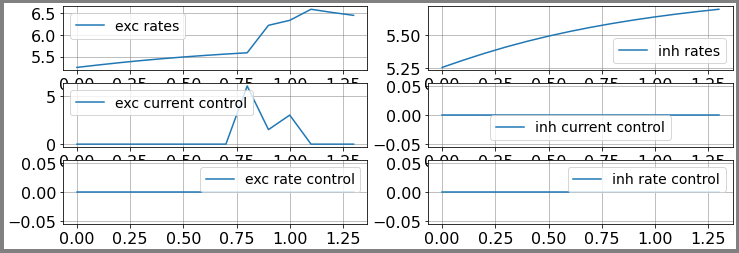

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


'\n[5.49133407 5.52669406 5.55862882 5.5874891  5.61357612 5.63715667\n 5.65847056 5.67773451 5.69514467 5.71087863 5.72509714 5.73794566\n 6.34955579 6.45004658 6.69052568 6.60668535 6.53157373 6.46439561\n 6.40458627 6.35114892 6.30319877]\n'

In [33]:
#0.1220741760704899

aln.params.duration = dur + dur_pre
setinitvars(high_state_vars)


control_ind2 = [0]
prec_var2 = [0]

control0 = aln.getZeroControl()
for j in control_ind2:
    control0[0,j,n_pre + 4] = 0.2 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 5] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 6] = 0.2 * max_cntrl #+ 0.3 * min_cntrl

plotFunc.plot_traces(aln, control0)

aln.params.duration = dur
target2 = aln.getZeroTarget()
target2[0,0,:] = aln.rates_exc[0,n_pre-1:]
target2[0,1,:] = aln.rates_inh[0,n_pre-1:]

print(target2[0,0,:] - target1[0,1,:])


"""
"""

In [60]:
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 100

start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
    
control1 = aln.getZeroControl()
#control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
#control3 = control0[:,:,n_pre-1:]
#control3[0,2,:] *= 1.
#control5 = bestControlA_A2[:,:,n_pre-1:-n_post+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target2,
        c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind2, prec_variables_ = prec_var2)

for j in control_ind2:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,n_pre-1:-n_post+1])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# -9.11609228e-02
# 0.002345565904937199

print("max grad value = ", np.amax(np.abs( grad[0,control_ind2[0],:] ) ) )
#0.14002287214095344

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
RUN  0 , total integrated cost =  0.14634853095594988
RUN  1 , total integrated cost =  0.12229594891698085
RUN  2 , total integrated cost =  0.12207721292697138
RUN  3 , total integrated cost =  0.12207420294766723
RUN  4 , total integrated cost =  0.12207417618054917
RUN  5 , total integrated cost =  0.12207417607211862
RUN  6 , total integrated cost =  0.1220741760705489
RUN  7 , total integrated cost =  0.12207417607049253
RUN  8 , total integrated cost =  0.12207417607049018
RUN  9 , total integrated cost =  0.12207417607049006
RUN  10 , total integrated cost =  0.12207417607049001
RUN  11 , total integrated cost =  0.12207417607048994
RUN  12 , total integrated cost =  0.12207417607048993
RUN  13 , total integrated cost =  0.1220741760704899
RUN  14 , total integrated cost =  0.1220741760704899
Control only changes marginally.
RUN  14 , total integrated cost =  0.1220741760704899
Improved over  14  iterations by  16.586674787167098  percent.
Problem in initial val

In [ ]:
""" 
phi 2 
phi 1 
0.0
0.0 0.007457234502589172 0.0 0.02642391696879717
-0.0 0.9210000000000003
0.0 -0.15288097465989026 0.0 -0.005943558039971573
0.0 0.0006054234408495596
"""

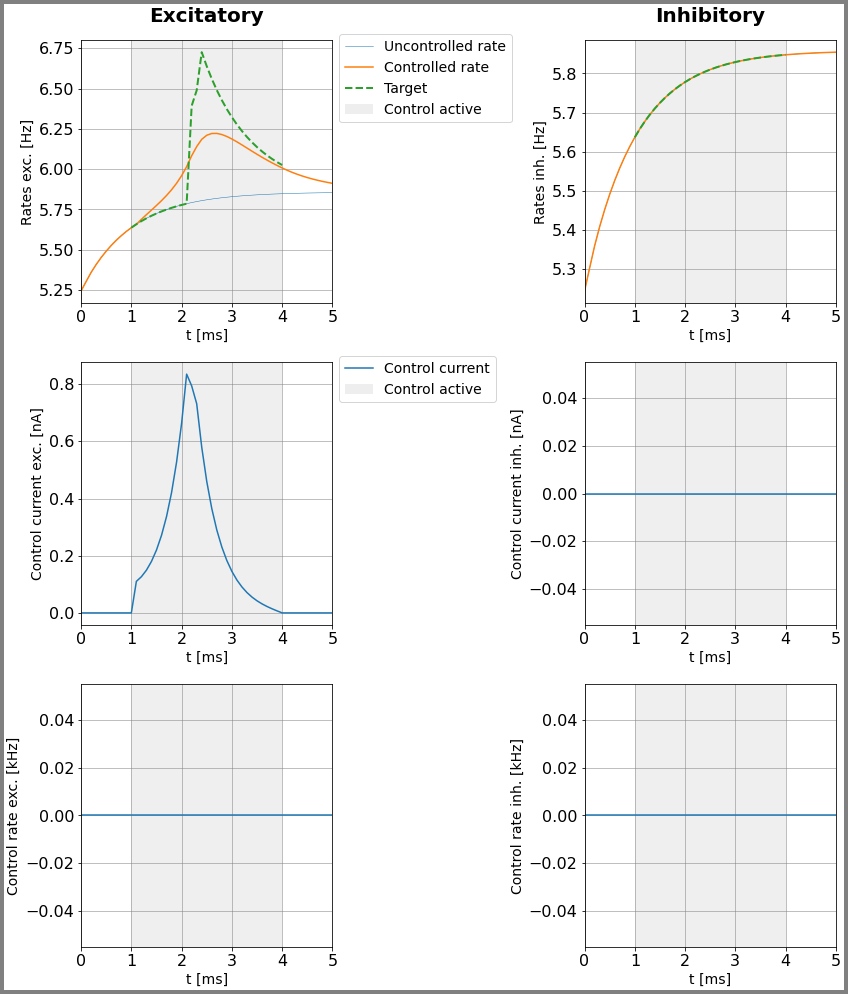

In [225]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [50]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA[:,:,n_pre-1:-n_pre+1]
#control4[0,2,:20] = 0.
#control6 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control4, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)
        
print(bestControlA_A2[0,control_ind[0],:])

# 0.009869078053036093

set cost params


NameError: name 'target' is not defined

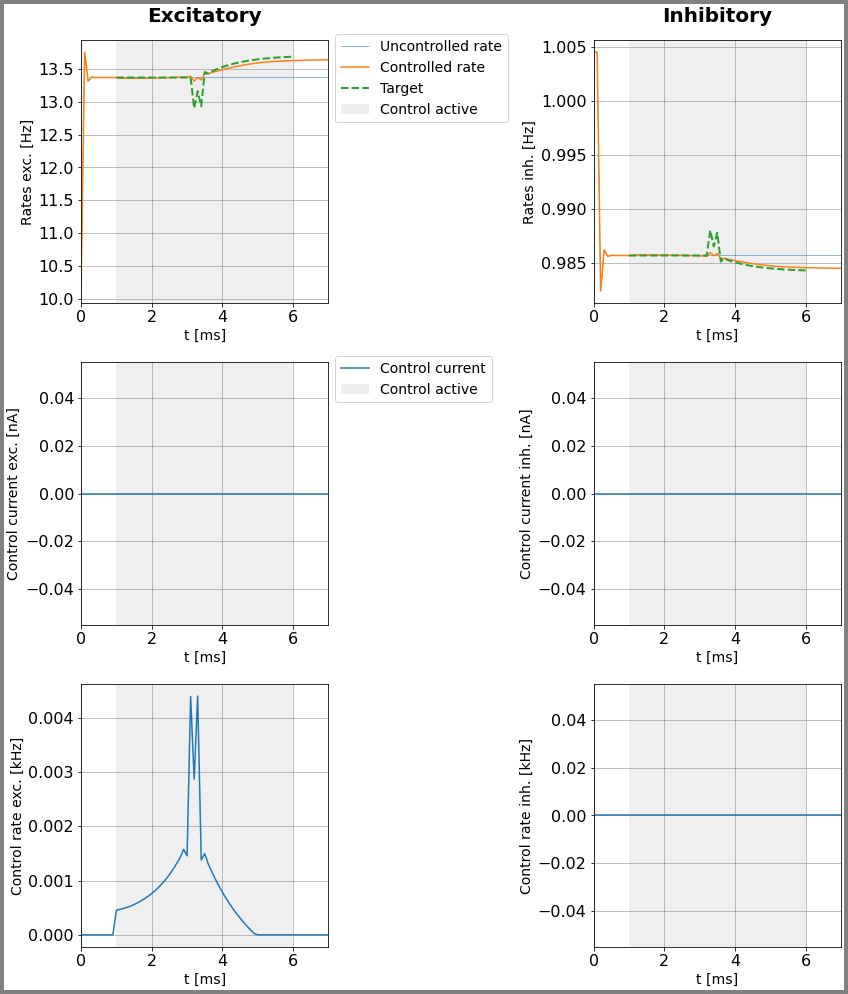

In [170]:
"""

"""

plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

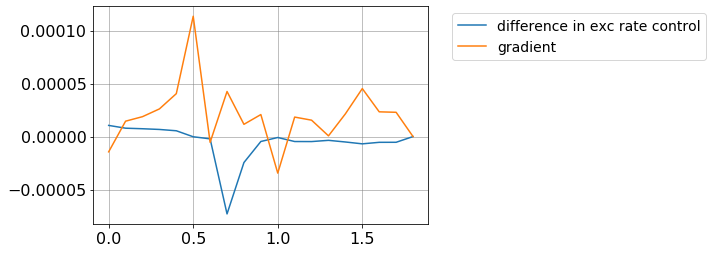

In [1219]:
diff = bestControlA_A2 - bestControlA
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

#plt.plot(t, diff[0,0,:], label="difference in exc current control")
#plt.plot(t, diff[0,1,:], label="difference in inh current control")
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.grid()
#plt.show()

plt.plot(t, diff[0,2,n_pre-1:-n_post+1], label="difference in exc rate control")
#plt.plot(t, diff[0,3,n_pre:-n_post], label="difference in inh rate control")
plt.plot(t, grad[0,2,:], label="gradient")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.

### What to take into account and don't forget
- if delay is present, always leave sufficient time steps before and after applying control
- allowing rates smaller than zero may cause trouble, because then same input can have different effect at different points of time
- is the fact that control enters computation at various points causing problems?
- if stuff of different orders of magnitude is competing, convergence is slow
- convergence in integration variables is much slower than in direct input
- make sure variables are in proper range: setting e.g. sigma to zero in time integration can cause problems
- the dynamics should not be explicitly dependent on time, otherwise adjoint formulation does not hold in this way
- apparently, also time-independent contributions mess up wiht the algorithm